# Backcasting analysis — cleaned version

This notebook keeps only the final analysis steps and avoids unnecessary recomputation. Intermediate products are loaded from disk when they already exist. Set `FORCE_RECOMPUTE = True` only if you want to rebuild cached products.

In [2]:
# ------------------------------------------------------------
# Reload session backup after kernel restart
# ------------------------------------------------------------

import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

backup_fp = "/mnt/eo/EO4Backcasting/_analysis/session_backups/backcasting_threshold_session_backup.pkl"

with open(backup_fp, "rb") as f:
    objects_loaded = pickle.load(f)

globals().update(objects_loaded)

print("Loaded objects:", list(objects_loaded.keys()))

Loaded objects: ['prob_fp', 'genus_fp', 'out_dir']


In [3]:
# ------------------------------------------------------------
# Reload saved threshold results from CSV
# robust version
# ------------------------------------------------------------

import os
import pandas as pd

out_dir = "/mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity"

files_to_check = {
    "df_total": "threshold_sensitivity_total.csv",
    "df_genus": "threshold_sensitivity_from_050_by_genus.csv",
    "df_ecoregion": "threshold_sensitivity_from_050_by_ecoregion.csv",
    "df_ecoregion_genus": "threshold_sensitivity_from_050_by_ecoregion_genus.csv",
    "df_class_check": "threshold_class_raster_check.csv"
}

loaded = {}

for obj_name, filename in files_to_check.items():
    fp = os.path.join(out_dir, filename)
    
    if os.path.exists(fp):
        loaded[obj_name] = pd.read_csv(fp)
        print(f"Loaded {obj_name}: {fp}")
    else:
        loaded[obj_name] = None
        print(f"Missing {obj_name}: {fp}")

df_total = loaded["df_total"]
df_genus = loaded["df_genus"]
df_ecoregion = loaded["df_ecoregion"]
df_ecoregion_genus = loaded["df_ecoregion_genus"]
df_class_check = loaded["df_class_check"]

if df_total is not None:
    display(df_total)

if df_genus is not None:
    display(df_genus.head())

if df_ecoregion is not None:
    display(df_ecoregion.head())

if df_ecoregion_genus is not None:
    display(df_ecoregion_genus.head())

if df_class_check is not None:
    display(df_class_check)

Missing df_total: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_total.csv
Loaded df_genus: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_genus.csv
Loaded df_ecoregion: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_ecoregion.csv
Loaded df_ecoregion_genus: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_sensitivity_from_050_by_ecoregion_genus.csv
Missing df_class_check: /mnt/eo/EO4Backcasting/_analysis/threshold_sensitivity/threshold_class_raster_check.csv


,threshold,genus_code,genus,n_pixels,area_ha,area_km2,total_group_pixels,total_group_area_ha,total_group_area_km2,relative_share_within_genus,relative_share_within_genus_percent
0,0.5,3,Fagus,84135234,7572171.06,75721.7106,164071490,14766434.10,147664.3410,0.512796,51.279618
1,0.5,0,Larix,5424323,488189.07,4881.8907,8971425,807428.25,8074.2825,0.604622,60.462223
2,0.5,6,Other broadleaf,203652960,18328766.40,183287.6640,364648554,32818369.86,328183.6986,0.558491,55.849107
3,0.5,5,Other needleleaf,11850840,1066575.60,10665.7560,22677583,2040982.47,20409.8247,0.522580,52.257950
4,0.5,1,Picea,187687049,16891834.41,168918.3441,297422520,26768026.80,267680.2680,0.631045,63.104518


,threshold,ecoregion_code,ecoregion,n_pixels,area_ha,area_km2,total_group_pixels,total_group_area_ha,total_group_area_km2,relative_share_within_ecoregion,relative_share_within_ecoregion_percent
0,0.5,1,Boreal,178181754,16036357.86,160363.5786,354629558,31916660.22,319166.6022,0.502445,50.244473
1,0.5,3,Mediterranean,110445531,9940097.79,99400.9779,203427358,18308462.22,183084.6222,0.542924,54.292369
2,0.5,2,Temperate,518347492,46651274.28,466512.7428,864965657,77846909.13,778469.0913,0.599269,59.926945
3,0.6,1,Boreal,99857884,8987209.56,89872.0956,354629558,31916660.22,319166.6022,0.281584,28.158365
4,0.6,3,Mediterranean,53505343,4815480.87,48154.8087,203427358,18308462.22,183084.6222,0.263019,26.301941


,threshold,ecoregion_code,ecoregion,genus_code,genus,n_pixels,area_ha,area_km2,total_group_pixels,total_group_area_ha,total_group_area_km2,relative_share_within_ecoregion_genus,relative_share_within_ecoregion_genus_percent
0,0.5,1,Boreal,3,Fagus,4330,389.70,3.8970,8823,794.07,7.9407,0.490763,49.076278
1,0.5,1,Boreal,0,Larix,4082,367.38,3.6738,7268,654.12,6.5412,0.561640,56.164007
2,0.5,1,Boreal,6,Other broadleaf,27550016,2479501.44,24795.0144,60144008,5412960.72,54129.6072,0.458068,45.806751
3,0.5,1,Boreal,5,Other needleleaf,27473,2472.57,24.7257,44309,3987.81,39.8781,0.620032,62.003205
4,0.5,1,Boreal,1,Picea,68936483,6204283.47,62042.8347,118185595,10636703.55,106367.0355,0.583290,58.329006


In [4]:
# ------------------------------------------------------------
# Imports and global settings
# ------------------------------------------------------------
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import bounds as window_bounds
from rasterio.windows import transform as window_transform
from rasterio.warp import reproject

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import Polygon, box
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
old_growth_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif")
old_growth_nodata0_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt08_4conn_5ha_nodata0.tif")
prob_fp = Path("/mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist.tif")
slope_fp = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/slope_NBR_1985_1995_mosaic.vrt")
undist_fp = Path("/mnt/eo/EFDA_v211/undisturbed_forest.tif")
forest_mask_fp = Path("/mnt/eo/EFDA_v211/forest_landuse_aligned.tif")
genus_fp = Path("/mnt/dss_project/lmandl/_backcasting/data/genus_map_europe.tif")
country_gpkg = Path("/mnt/eo/EO4Backcasting/_data/CNTR_RG_10M_2024_3035.gpkg")

# ------------------------------------------------------------
# Output/cache folders
# ------------------------------------------------------------
out_dir = Path("/mnt/eo/EO4Backcasting/figures")
out_dir.mkdir(parents=True, exist_ok=True)

prob_genus_fig_dir = Path("/mnt/eo/EO4Backcasting/figures/genus_probability")
prob_genus_fig_dir.mkdir(parents=True, exist_ok=True)

cache_dir = Path("/mnt/eo/EO4Backcasting/_analysis_cache")
cache_dir.mkdir(parents=True, exist_ok=True)

aligned_dir = Path("/mnt/eo/EO4Backcasting/_data_aligned")
aligned_dir.mkdir(parents=True, exist_ok=True)

genus_aligned_fp = aligned_dir / "genus_map_europe_aligned_to_probability_30m.tif"

# Cached analysis products
nbr_sample_csv = cache_dir / "nbr_trend_sample_oldgrowth_vs_undisturbed.csv"
genus_counts_csv = cache_dir / "continuously_undisturbed_area_by_genus.csv"
genus_country_csv = cache_dir / "continuously_undisturbed_area_by_genus_country.csv"
genus_share_csv = cache_dir / "continuously_undisturbed_share_by_genus.csv"
country_share_csv = cache_dir / "continuously_undisturbed_share_by_country.csv"
hex_gpkg = cache_dir / "continuously_undisturbed_by_small_clipped_hexagon.gpkg"
prob_genus_sample_csv = cache_dir / "probability_by_genus_sample.csv"

FORCE_RECOMPUTE = False

# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------
pixel_area_ha = 0.09       # 30 m pixel = 900 m² = 0.09 ha
forest_value = 1
country_name_col = "NAME_ENGL"
exclude_russia = True

# Hexagon settings used in the final version of the original notebook
hex_radius = 17_500
min_forest_area_ha = 500

# Text labels for figures; variable names stay as oldgrowth to avoid rewriting all logic.
forest_label = "continuously undisturbed forest"
forest_label_cap = "Continuously undisturbed forest"

genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees",
}

genus_colors = {
    "Picea": "#2C7FB8",
    "Pinus": "#F28E2B",
    "Fagus": "#59A14F",
    "Quercus": "#E15759",
    "Larix": "#B07AA1",
    "Other broadleaf": "#76B7B2",
    "Other needleleaf": "#EDC948",
    "Other": "#BDBDBD",
}

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
    "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

mainland_bbox_4326 = box(-11, 34, 35, 72)


In [5]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def create_hex_grid(bounds, hex_radius, crs):
    """Create a flat-top hexagon grid for a given bounding box."""
    minx, miny, maxx, maxy = bounds
    dx = 1.5 * hex_radius
    dy = np.sqrt(3) * hex_radius

    hexagons = []
    hex_ids = []
    x = minx - 2 * hex_radius
    col = 0
    hex_id = 1

    while x < maxx + 2 * hex_radius:
        y_offset = 0 if col % 2 == 0 else dy / 2
        y = miny - dy

        while y < maxy + dy:
            cy = y + y_offset
            angles = np.deg2rad([0, 60, 120, 180, 240, 300])
            coords = [(x + hex_radius * np.cos(a), cy + hex_radius * np.sin(a)) for a in angles]
            hexagons.append(Polygon(coords))
            hex_ids.append(hex_id)
            hex_id += 1
            y += dy

        x += dx
        col += 1

    return gpd.GeoDataFrame({"hex_id": hex_ids}, geometry=hexagons, crs=crs)


def load_europe_countries(target_crs=None, clip_mainland=False):
    """Load countries, keep European countries, optionally reproject and remove remote/overseas parts."""
    countries = gpd.read_file(country_gpkg)
    countries["country"] = countries[country_name_col].astype(str).str.strip()

    countries = countries[countries["country"].isin(european_countries)].copy()
    if exclude_russia:
        countries = countries[countries["country"] != "Russian Federation"].copy()

    countries = countries[countries.geometry.notna() & ~countries.geometry.is_empty].copy()
    countries["geometry"] = countries.geometry.make_valid()

    if clip_mainland:
        countries_4326 = countries.to_crs(4326)
        parts = countries_4326.explode(index_parts=False).reset_index(drop=True)
        rep = parts.representative_point()
        keep = (rep.x >= -11) & (rep.x <= 35) & (rep.y >= 34) & (rep.y <= 72)
        parts = parts.loc[keep].copy()
        bbox_gdf = gpd.GeoDataFrame(geometry=[mainland_bbox_4326], crs=4326)
        parts = gpd.clip(parts, bbox_gdf)
        countries = parts.dissolve(by="country", as_index=False)

    if target_crs is not None and countries.crs != target_crs:
        countries = countries.to_crs(target_crs)

    return countries


def ensure_aligned_genus():
    """Load aligned genus raster if present; otherwise create it once."""
    if genus_aligned_fp.exists() and not FORCE_RECOMPUTE:
        print(f"Using existing aligned genus raster: {genus_aligned_fp}")
        return genus_aligned_fp

    print("Creating aligned genus raster...")
    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        profile = prob_src.profile.copy()
        profile.update(
            dtype="uint8",
            count=1,
            nodata=255,
            compress="deflate",
            tiled=True,
            blockxsize=512,
            blockysize=512,
            BIGTIFF="YES",
        )

        with rasterio.open(genus_aligned_fp, "w", **profile) as dst:
            reproject(
                source=rasterio.band(genus_src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=genus_src.transform,
                src_crs=genus_src.crs,
                src_nodata=genus_src.nodata,
                dst_transform=prob_src.transform,
                dst_crs=prob_src.crs,
                dst_nodata=255,
                resampling=Resampling.nearest,
            )

    print(f"Written: {genus_aligned_fp}")
    return genus_aligned_fp


def add_genus_names(df, code_col="genus_code"):
    df = df.copy()
    df["genus"] = df[code_col].map(genus_lookup)
    df["genus"] = df["genus"].fillna("Code " + df[code_col].astype(str))
    return df


## 1. NBR trend comparison

The sample is loaded from cache if available. The expensive random sampling from rasters is only repeated if the CSV is missing or `FORCE_RECOMPUTE = True`.

In [7]:
# ------------------------------------------------------------
# Load or create random sample for NBR trend comparison
# ------------------------------------------------------------
def sample_nbr_trend(n_samples=50_000, seed=42):
    rng = np.random.default_rng(seed)

    with rasterio.open(old_growth_nodata0_fp) as old_src, \
         rasterio.open(undist_fp) as undist_src, \
         rasterio.open(prob_fp) as prob_src, \
         rasterio.open(slope_fp) as slope_src:

        same_grid = (
            old_src.width == undist_src.width == prob_src.width == slope_src.width and
            old_src.height == undist_src.height == prob_src.height == slope_src.height and
            old_src.transform == undist_src.transform == prob_src.transform == slope_src.transform
        )
        if not same_grid:
            raise ValueError("Input rasters are not on the same grid.")

        total_pixels = old_src.height * old_src.width
        sample_idx = rng.choice(total_pixels, size=n_samples, replace=False)
        rows, cols = np.unravel_index(sample_idx, (old_src.height, old_src.width))
        xs, ys = rasterio.transform.xy(old_src.transform, rows, cols)
        pts = list(zip(xs, ys))

        old_vals = np.array([v[0] for v in tqdm(old_src.sample(pts), total=len(pts), desc="Sampling continuity")])
        undist_vals = np.array([v[0] for v in tqdm(undist_src.sample(pts), total=len(pts), desc="Sampling undisturbed")])
        prob_vals = np.array([v[0] for v in tqdm(prob_src.sample(pts), total=len(pts), desc="Sampling probability")])
        slope_vals = np.array([v[0] for v in tqdm(slope_src.sample(pts), total=len(pts), desc="Sampling NBR slope")])

        valid = np.isfinite(old_vals) & np.isfinite(undist_vals) & np.isfinite(prob_vals) & np.isfinite(slope_vals)
        for src, vals in [(old_src, old_vals), (undist_src, undist_vals), (prob_src, prob_vals), (slope_src, slope_vals)]:
            if src.nodata is not None:
                valid &= vals != src.nodata

    return pd.DataFrame({
        "oldgrowth": old_vals[valid],
        "undisturbed": undist_vals[valid],
        "probability": prob_vals[valid],
        "slope": slope_vals[valid],
    })

if nbr_sample_csv.exists() and not FORCE_RECOMPUTE:
    df_nbr = pd.read_csv(nbr_sample_csv)
    print(f"Loaded cached NBR sample: {nbr_sample_csv}")
else:
    df_nbr = sample_nbr_trend(n_samples=50_000, seed=42)
    df_nbr.to_csv(nbr_sample_csv, index=False)
    print(f"Written: {nbr_sample_csv}")

g1 = df_nbr[df_nbr["oldgrowth"] == 1].copy()
g2 = df_nbr[(df_nbr["undisturbed"] == 1) & (df_nbr["oldgrowth"] != 1)].copy()

print("Sampled valid pixels:", len(df_nbr))
print("Continuously undisturbed pixels:", len(g1))
print("Undisturbed forest excluding continuously undisturbed pixels:", len(g2))


Loaded cached NBR sample: /mnt/eo/EO4Backcasting/_analysis_cache/nbr_trend_sample_oldgrowth_vs_undisturbed.csv
Sampled valid pixels: 83
Continuously undisturbed pixels: 83
Undisturbed forest excluding continuously undisturbed pixels: 0


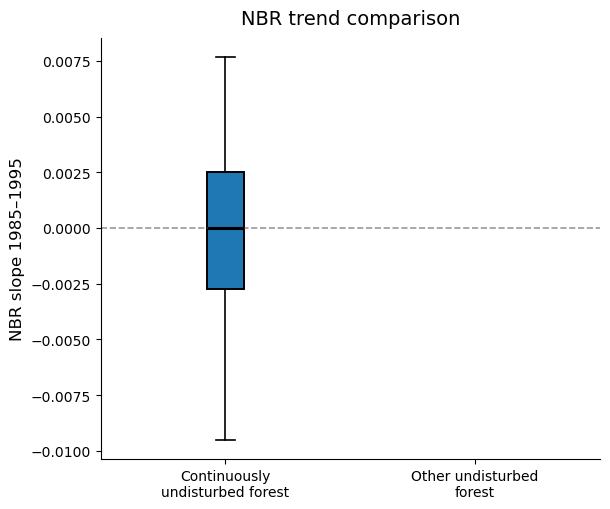

Saved PNG: /mnt/eo/EO4Backcasting/figures/nbr_trend_boxplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/nbr_trend_boxplot.svg


In [8]:
# ------------------------------------------------------------
# Plot: NBR trend comparison
# ------------------------------------------------------------
plot_df = pd.concat([
    g1.assign(group="Continuously undisturbed forest"),
    g2.assign(group="Other undisturbed forest"),
])

fig, ax = plt.subplots(figsize=(6.2, 5.2))

ax.boxplot(
    [
        plot_df.loc[plot_df["group"] == "Continuously undisturbed forest", "slope"].dropna(),
        plot_df.loc[plot_df["group"] == "Other undisturbed forest", "slope"].dropna(),
    ],
    tick_labels=["Continuously\nundisturbed forest", "Other undisturbed\nforest"],
    showfliers=False,
    patch_artist=True,
    medianprops=dict(linewidth=2.2, color="black"),
    boxprops=dict(linewidth=1.4),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

ax.axhline(0, linestyle="--", linewidth=1.2, color="grey", alpha=0.8)
ax.set_ylabel("NBR slope 1985–1995", fontsize=12)
ax.set_title("NBR trend comparison", fontsize=14, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

out_png = out_dir / "nbr_trend_boxplot.png"
out_svg = out_dir / "nbr_trend_boxplot.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 2. Tree genus composition

The raster counting is cached as tables. Existing CSV files are loaded directly.

In [9]:
# ------------------------------------------------------------
# Load or compute genus area within continuously undisturbed forest
# ------------------------------------------------------------
def count_genus_area():
    counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting genus within continuously undisturbed pixels"):
                old = old_src.read(1, window=window)
                if not np.any(old == 1):
                    continue

                genus = genus_vrt.read(1, window=window)
                valid = (old == 1) & (genus != 255) & np.isfinite(genus)
                vals = genus[valid]

                if vals.size > 0:
                    unique, counts = np.unique(vals.astype(np.int32), return_counts=True)
                    counter.update(dict(zip(unique, counts)))

    df = pd.DataFrame(counter.items(), columns=["genus_code", "n_pixels"])
    df["area_ha"] = df["n_pixels"] * pixel_area_ha
    df["percent"] = df["n_pixels"] / df["n_pixels"].sum() * 100
    df = add_genus_names(df)
    df = df.sort_values("area_ha", ascending=False)
    return df

if genus_counts_csv.exists() and not FORCE_RECOMPUTE:
    df_counts = pd.read_csv(genus_counts_csv)
    print(f"Loaded cached genus counts: {genus_counts_csv}")
else:
    df_counts = count_genus_area()
    df_counts.to_csv(genus_counts_csv, index=False)
    print(f"Written: {genus_counts_csv}")

display(df_counts.head(20))


Loaded cached genus counts: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus.csv


,genus_code,n_pixels,area_ha,percent,genus
0,1,20204726,1818425.34,69.129702,Picea
1,2,6900251,621022.59,23.608946,Pinus
2,6,783092,70478.28,2.679320,Other broadleaf
3,5,491674,44250.66,1.682244,Other needleleaf
4,7,396445,35680.05,1.356421,No trees
5,3,319878,28789.02,1.094450,Fagus
6,4,75638,6807.42,0.258793,Quercus
7,0,55568,5001.12,0.190124,Larix


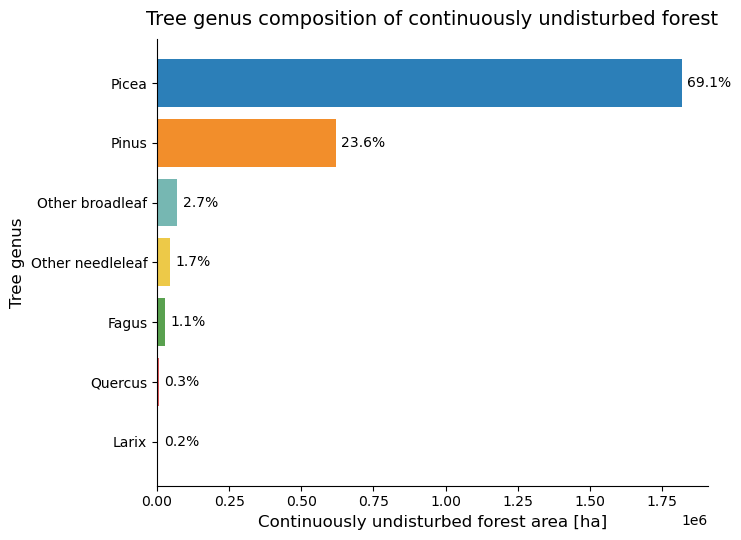

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_genus_barplot.svg


In [6]:
# ------------------------------------------------------------
# Plot: genus composition of continuously undisturbed forest
# ------------------------------------------------------------
plot_df = df_counts[df_counts["genus"] != "No trees"].copy()
plot_df = plot_df.sort_values("area_ha", ascending=True)
plot_df["color"] = plot_df["genus"].map(genus_colors).fillna("#BDBDBD")

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.barh(plot_df["genus"], plot_df["area_ha"], color=plot_df["color"], edgecolor="none")
ax.set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
ax.set_ylabel("Tree genus", fontsize=12)
ax.set_title(f"Tree genus composition of {forest_label}", fontsize=14, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

xmax = plot_df["area_ha"].max()
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row["area_ha"] + xmax * 0.01, i, f'{row["percent"]:.1f}%', va="center", fontsize=10)

plt.tight_layout()

out_png = out_dir / "old_growth_genus_barplot.png"
out_svg = out_dir / "old_growth_genus_barplot.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


In [11]:
# ------------------------------------------------------------
# Load or compute total genus area and continuously undisturbed share by genus
# ------------------------------------------------------------
def count_total_and_undisturbed_genus_area():
    counter_total = Counter()
    counter_oldgrowth = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting total and continuously undisturbed genus area"):
                old = old_src.read(1, window=window)
                genus = genus_vrt.read(1, window=window)

                valid_genus = (genus != 255) & np.isfinite(genus) & (genus != 7)
                vals_total = genus[valid_genus].astype(np.int16)
                if vals_total.size > 0:
                    unique, counts = np.unique(vals_total, return_counts=True)
                    counter_total.update(dict(zip(unique, counts)))

                vals_old = genus[valid_genus & (old == 1)].astype(np.int16)
                if vals_old.size > 0:
                    unique, counts = np.unique(vals_old, return_counts=True)
                    counter_oldgrowth.update(dict(zip(unique, counts)))

    df_total = pd.DataFrame(counter_total.items(), columns=["genus_code", "total_pixels"])
    df_old = pd.DataFrame(counter_oldgrowth.items(), columns=["genus_code", "oldgrowth_pixels"])
    df = df_total.merge(df_old, on="genus_code", how="left")
    df["oldgrowth_pixels"] = df["oldgrowth_pixels"].fillna(0)
    df["total_area_ha"] = df["total_pixels"] * pixel_area_ha
    df["oldgrowth_area_ha"] = df["oldgrowth_pixels"] * pixel_area_ha
    df["oldgrowth_share_percent"] = df["oldgrowth_area_ha"] / df["total_area_ha"] * 100
    df = add_genus_names(df)
    return df.sort_values("oldgrowth_share_percent", ascending=False)

if genus_share_csv.exists() and not FORCE_RECOMPUTE:
    df_genus_share = pd.read_csv(genus_share_csv)
    print(f"Loaded cached genus share table: {genus_share_csv}")
else:
    df_genus_share = count_total_and_undisturbed_genus_area()
    df_genus_share.to_csv(genus_share_csv, index=False)
    print(f"Written: {genus_share_csv}")

display(df_genus_share)


Loaded cached genus share table: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_genus.csv


,genus_code,total_pixels,oldgrowth_pixels,total_area_ha,oldgrowth_area_ha,oldgrowth_share_percent,genus
0,1,478199729,20204726,43037975.61,1818425.34,4.225165,Picea
1,5,38353309,491674,3451797.81,44250.66,1.281960,Other needleleaf
2,2,674970677,6900251,60747360.93,621022.59,1.022304,Pinus
3,0,13422735,55568,1208046.15,5001.12,0.413984,Larix
4,3,203003367,319878,18270303.03,28789.02,0.157573,Fagus
5,6,766017671,783092,68941590.39,70478.28,0.102229,Other broadleaf
6,4,324662867,75638,29219658.03,6807.42,0.023297,Quercus


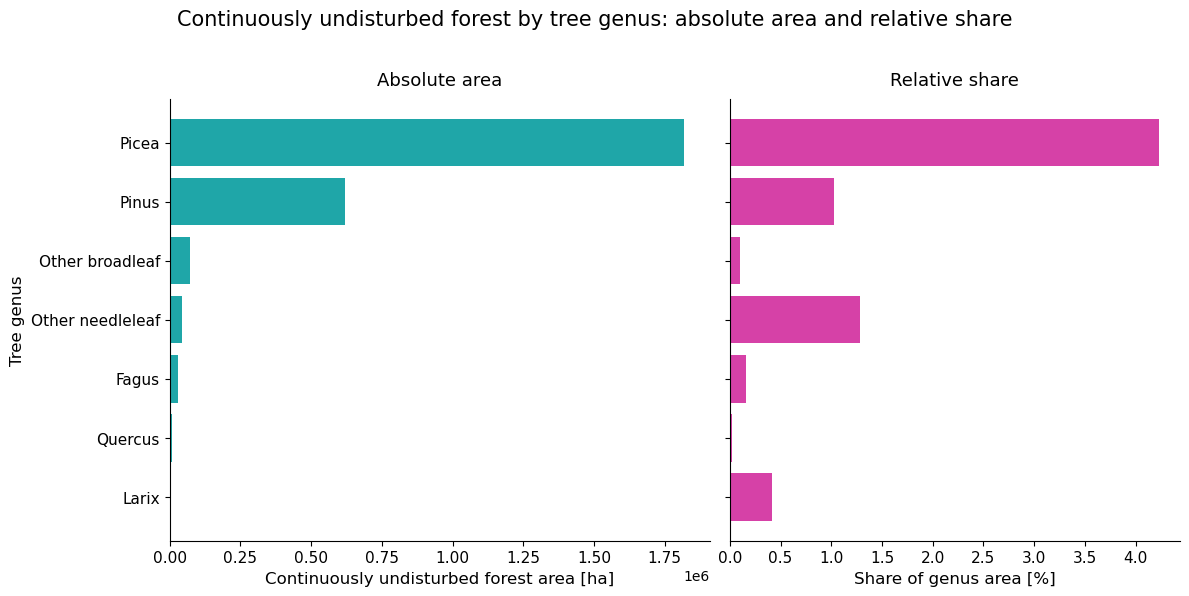

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_and_relative_by_genus.svg


In [8]:
# ------------------------------------------------------------
# Plot: absolute area and relative share by genus
# ------------------------------------------------------------
plot_df = df_genus_share.sort_values("oldgrowth_area_ha", ascending=True).copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5.8),
    sharey=True,
    gridspec_kw={"width_ratios": [1.2, 1]},
)

axes[0].barh(plot_df["genus"], plot_df["oldgrowth_area_ha"], color="#1FA6A8")
axes[0].set_xlabel(f"{forest_label_cap} area [ha]", fontsize=12)
axes[0].set_ylabel("Tree genus", fontsize=12)
axes[0].set_title("Absolute area", fontsize=13, pad=10)

axes[1].barh(plot_df["genus"], plot_df["oldgrowth_share_percent"], color="#D641A7")
axes[1].set_xlabel("Share of genus area [%]", fontsize=12)
axes[1].set_title("Relative share", fontsize=13, pad=10)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)

fig.suptitle(f"{forest_label_cap} by tree genus: absolute area and relative share", fontsize=15, y=1.02)
plt.tight_layout()

out_png = out_dir / "old_growth_absolute_and_relative_by_genus.png"
out_svg = out_dir / "old_growth_absolute_and_relative_by_genus.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 3. Country-level area and share

Country-by-genus and country forest-share tables are cached, so the expensive block-wise rasterization is not repeated unless needed.

In [9]:
# ------------------------------------------------------------
# Load or compute country x genus table
# ------------------------------------------------------------
def count_genus_by_country():
    with rasterio.open(old_growth_fp) as old_src:
        countries = load_europe_countries(target_crs=old_src.crs, clip_mainland=False)

    countries = countries.reset_index(drop=True)
    countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)
    country_lookup = dict(zip(countries["country_code"], countries["country"]))
    sindex = countries.sindex
    counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(genus_fp) as genus_src:
        with WarpedVRT(
            genus_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=genus_src.nodata,
            nodata=255,
        ) as genus_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting genus and country"):
                old = old_src.read(1, window=window)
                if not np.any(old == 1):
                    continue

                genus = genus_vrt.read(1, window=window)
                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)

                candidate_idx = list(sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                countries_block = countries.iloc[candidate_idx].copy()
                countries_block = countries_block[countries_block.intersects(block_geom)]
                if countries_block.empty:
                    continue

                country_block = rasterize(
                    shapes=zip(countries_block.geometry, countries_block["country_code"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid = (old == 1) & (genus != 255) & (genus != 7) & (country_block != 0) & np.isfinite(genus)
                genus_vals = genus[valid].astype(np.int16)
                country_vals = country_block[valid].astype(np.int32)

                if genus_vals.size > 0:
                    counter.update(zip(genus_vals, country_vals))

    df = pd.DataFrame([(g, c, n) for (g, c), n in counter.items()], columns=["genus_code", "country_code", "n_pixels"])
    df["area_ha"] = df["n_pixels"] * pixel_area_ha
    df = add_genus_names(df)
    df["country"] = df["country_code"].map(country_lookup).fillna("Unknown country")
    return df.sort_values("area_ha", ascending=False)

if genus_country_csv.exists() and not FORCE_RECOMPUTE:
    df_gc = pd.read_csv(genus_country_csv)
    print(f"Loaded cached country-genus table: {genus_country_csv}")
else:
    df_gc = count_genus_by_country()
    df_gc.to_csv(genus_country_csv, index=False)
    print(f"Written: {genus_country_csv}")

display(df_gc.head(20))


Counting genus and country:   0%|          | 0/140000 [00:00<?, ?it/s]

Written: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_area_by_genus_country.csv


,genus_code,country_code,n_pixels,area_ha,genus,country
8,1,30,3691596,332243.64,Picea,Sweden
65,1,12,3499630,314966.70,Picea,Germany
55,2,33,2279209,205128.81,Pinus,Poland
97,1,11,1902938,171264.42,Picea,Czechia
128,1,35,1813235,163191.15,Picea,Romania
5,1,8,1727891,155510.19,Picea,Finland
122,1,3,1468063,132125.67,Picea,Austria
7,2,30,1448767,130389.03,Pinus,Sweden
56,1,33,1182918,106462.62,Picea,Poland
2,1,32,1107036,99633.24,Picea,Norway


In [10]:
# ------------------------------------------------------------
# Load or compute share of continuously undisturbed forest by country
# ------------------------------------------------------------
def count_country_forest_share():
    with rasterio.open(old_growth_fp) as old_src:
        countries = load_europe_countries(target_crs=old_src.crs, clip_mainland=False)

    countries = countries.reset_index(drop=True)
    countries["country_code"] = np.arange(1, len(countries) + 1).astype(np.int32)
    country_lookup = dict(zip(countries["country_code"], countries["country"]))
    sindex = countries.sindex

    forest_counter = Counter()
    oldgrowth_counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:
        with WarpedVRT(
            forest_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=forest_src.nodata,
            nodata=0,
        ) as forest_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting forest and continuously undisturbed area by country"):
                old = old_src.read(1, window=window)
                forest = forest_vrt.read(1, window=window)

                if not (np.any(forest == forest_value) or np.any(old == 1)):
                    continue

                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)
                candidate_idx = list(sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                countries_block = countries.iloc[candidate_idx].copy()
                countries_block = countries_block[countries_block.intersects(block_geom)]
                if countries_block.empty:
                    continue

                country_block = rasterize(
                    shapes=zip(countries_block.geometry, countries_block["country_code"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid_country = country_block != 0
                forest_ids = country_block[valid_country & (forest == forest_value)].astype(np.int32)
                old_ids = country_block[valid_country & (forest == forest_value) & (old == 1)].astype(np.int32)

                if forest_ids.size > 0:
                    unique, counts = np.unique(forest_ids, return_counts=True)
                    forest_counter.update(dict(zip(unique, counts)))

                if old_ids.size > 0:
                    unique, counts = np.unique(old_ids, return_counts=True)
                    oldgrowth_counter.update(dict(zip(unique, counts)))

    df_forest = pd.DataFrame(forest_counter.items(), columns=["country_code", "forest_pixels"])
    df_old = pd.DataFrame(oldgrowth_counter.items(), columns=["country_code", "oldgrowth_pixels"])
    df = df_forest.merge(df_old, on="country_code", how="left")
    df["oldgrowth_pixels"] = df["oldgrowth_pixels"].fillna(0)
    df["country"] = df["country_code"].map(country_lookup)
    df["forest_area_ha"] = df["forest_pixels"] * pixel_area_ha
    df["oldgrowth_area_ha"] = df["oldgrowth_pixels"] * pixel_area_ha
    df["oldgrowth_share_percent"] = df["oldgrowth_area_ha"] / df["forest_area_ha"] * 100
    return df.sort_values("oldgrowth_share_percent", ascending=False)

if country_share_csv.exists() and not FORCE_RECOMPUTE:
    df_country_share = pd.read_csv(country_share_csv)
    print(f"Loaded cached country share table: {country_share_csv}")
else:
    df_country_share = count_country_forest_share()
    df_country_share.to_csv(country_share_csv, index=False)
    print(f"Written: {country_share_csv}")

display(df_country_share.head(20))


Counting forest and continuously undisturbed area by country:   0%|          | 0/140000 [00:00<?, ?it/s]

Written: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_country.csv


,country_code,forest_pixels,oldgrowth_pixels,country,forest_area_ha,oldgrowth_area_ha,oldgrowth_share_percent
16,11,36306141,2235458.0,Czechia,3267552.69,201191.22,6.157245
11,12,135784176,5084944.0,Germany,12220575.84,457644.96,3.744872
22,3,49986108,1550939.0,Austria,4498749.72,139584.51,3.102740
10,33,123880266,3712089.0,Poland,11149223.94,334088.01,2.996514
4,14,31179762,878894.0,Estonia,2806178.58,79100.46,2.818796
20,35,98257774,1904590.0,Romania,8843199.66,171413.10,1.938361
5,24,42973013,715893.0,Latvia,3867571.17,64430.37,1.665913
30,4,33448993,548789.0,Bosnia and Herzegovina,3010409.37,49391.01,1.640674
2,30,340033918,5301155.0,Sweden,30603052.62,477103.95,1.559008
26,36,14824841,196501.0,Slovenia,1334235.69,17685.09,1.325485


In [10]:
# ------------------------------------------------------------
# Plot: country share barplot and map
# ------------------------------------------------------------
cmap = plt.get_cmap("YlGnBu")
vmin = 0
vmax = df_country_share["oldgrowth_share_percent"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

df_country_share["plot_color"] = df_country_share["oldgrowth_share_percent"].apply(lambda x: cmap(norm(x)))

country_bar = df_country_share.sort_values("oldgrowth_share_percent", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8.5, 10))
ax.barh(country_bar["country"], country_bar["oldgrowth_share_percent"], color=country_bar["plot_color"])
ax.set_xlabel(f"{forest_label_cap} [% of forest area]", fontsize=12)
ax.set_ylabel("Country", fontsize=12)
ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()

out_png_bar = out_dir / "old_growth_share_of_forest_by_country_barplot_matched_colors.png"
out_svg_bar = out_dir / "old_growth_share_of_forest_by_country_barplot_matched_colors.svg"
fig.savefig(out_png_bar, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_bar, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved barplot PNG:", out_png_bar)
print("Saved barplot SVG:", out_svg_bar)

# Map
with rasterio.open(old_growth_fp) as src:
    countries_map = load_europe_countries(target_crs=src.crs, clip_mainland=False)

countries_map = countries_map.merge(
    df_country_share[["country", "oldgrowth_share_percent", "plot_color"]],
    on="country",
    how="left",
)
countries_map["oldgrowth_share_percent"] = countries_map["oldgrowth_share_percent"].fillna(0)
countries_map["plot_color"] = countries_map["plot_color"].fillna("#eeeeee")
countries_map = countries_map.to_crs(4326)

fig, ax = plt.subplots(figsize=(8, 8))
countries_map.plot(color=countries_map["plot_color"], linewidth=0.5, edgecolor="white", ax=ax)
countries_map.boundary.plot(ax=ax, color="0.7", linewidth=0.35)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.75, fraction=0.045, pad=0.04)
cbar.set_label(f"{forest_label_cap} [% of forest area]", fontsize=11)
cbar.ax.tick_params(labelsize=12)

ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.set_title(f"Relative share of {forest_label} by country", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()

out_png_map = out_dir / "old_growth_share_of_forest_by_country_map_matched_colors.png"
out_svg_map = out_dir / "old_growth_share_of_forest_by_country_map_matched_colors.svg"
fig.savefig(out_png_map, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_map, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved map PNG:", out_png_map)
print("Saved map SVG:", out_svg_map)


NameError: name 'df_country_share' is not defined

## 4. Hexagon maps

This replaces the repeated hexagon workflows with one cached product. If the GeoPackage exists, it is loaded directly; otherwise, the clipped hexagons and raster counts are computed once and written to disk.

In [19]:
# ------------------------------------------------------------
# Load or compute clipped hexagon summary
# ------------------------------------------------------------
def compute_hexagon_summary():
    with rasterio.open(old_growth_fp) as old_src:
        countries_eur = load_europe_countries(target_crs=old_src.crs, clip_mainland=True)

    europe_geom = countries_eur.geometry.union_all()
    europe_bounds = countries_eur.total_bounds

    hexes = create_hex_grid(bounds=europe_bounds, hex_radius=hex_radius, crs=countries_eur.crs)
    hexes = hexes[hexes.intersects(europe_geom)].copy()

    europe_clip = gpd.GeoDataFrame(geometry=[europe_geom], crs=countries_eur.crs)
    hexes = gpd.clip(hexes, europe_clip)
    hexes = hexes[hexes.geometry.notna() & ~hexes.geometry.is_empty].copy()
    hexes["geometry"] = hexes.geometry.make_valid()
    hexes = hexes.reset_index(drop=True)
    hexes["hex_id"] = np.arange(1, len(hexes) + 1).astype(np.int32)

    print("Number of clipped hexagons:", len(hexes))

    hex_sindex = hexes.sindex
    forest_counter = Counter()
    oldgrowth_counter = Counter()

    with rasterio.open(old_growth_fp) as old_src, rasterio.open(forest_mask_fp) as forest_src:
        with WarpedVRT(
            forest_src,
            crs=old_src.crs,
            transform=old_src.transform,
            width=old_src.width,
            height=old_src.height,
            resampling=Resampling.nearest,
            src_nodata=forest_src.nodata,
            nodata=0,
        ) as forest_vrt:
            windows = [window for _, window in old_src.block_windows(1)]

            for window in tqdm(windows, desc="Counting forest and continuously undisturbed area by clipped hexagon"):
                old = old_src.read(1, window=window)
                forest = forest_vrt.read(1, window=window)

                if not (np.any(forest == forest_value) or np.any(old == 1)):
                    continue

                b = window_bounds(window, old_src.transform)
                block_geom = box(*b)

                candidate_idx = list(hex_sindex.intersection(block_geom.bounds))
                if not candidate_idx:
                    continue

                hex_block = hexes.iloc[candidate_idx].copy()
                hex_block = hex_block[hex_block.intersects(block_geom)]
                if hex_block.empty:
                    continue

                hex_raster = rasterize(
                    shapes=zip(hex_block.geometry, hex_block["hex_id"]),
                    out_shape=old.shape,
                    transform=window_transform(window, old_src.transform),
                    fill=0,
                    dtype="int32",
                    all_touched=False,
                )

                valid_hex = hex_raster != 0
                valid_forest = valid_hex & (forest == forest_value)
                forest_ids = hex_raster[valid_forest].astype(np.int32)
                old_ids = hex_raster[valid_forest & (old == 1)].astype(np.int32)

                if forest_ids.size > 0:
                    unique, counts = np.unique(forest_ids, return_counts=True)
                    forest_counter.update(dict(zip(unique, counts)))

                if old_ids.size > 0:
                    unique, counts = np.unique(old_ids, return_counts=True)
                    oldgrowth_counter.update(dict(zip(unique, counts)))

    df_forest_hex = pd.DataFrame(forest_counter.items(), columns=["hex_id", "forest_pixels"])
    df_old_hex = pd.DataFrame(oldgrowth_counter.items(), columns=["hex_id", "oldgrowth_pixels"])
    df_hex = df_forest_hex.merge(df_old_hex, on="hex_id", how="left")
    df_hex["oldgrowth_pixels"] = df_hex["oldgrowth_pixels"].fillna(0)
    df_hex["forest_area_ha"] = df_hex["forest_pixels"] * pixel_area_ha
    df_hex["oldgrowth_area_ha"] = df_hex["oldgrowth_pixels"] * pixel_area_ha
    df_hex["oldgrowth_share_percent"] = df_hex["oldgrowth_area_ha"] / df_hex["forest_area_ha"] * 100

    hexes_plot = hexes.merge(df_hex, on="hex_id", how="left")
    hexes_plot = hexes_plot[
        hexes_plot["forest_area_ha"].notna() &
        (hexes_plot["forest_area_ha"] >= min_forest_area_ha)
    ].copy()

    return hexes_plot, countries_eur

if hex_gpkg.exists() and not FORCE_RECOMPUTE:
    hexes_plot = gpd.read_file(hex_gpkg, layer="hexes")
    with rasterio.open(old_growth_fp) as src:
        countries_eur = load_europe_countries(target_crs=src.crs, clip_mainland=True)
    print(f"Loaded cached hexagon product: {hex_gpkg}")
else:
    hexes_plot, countries_eur = compute_hexagon_summary()
    hexes_plot.to_file(hex_gpkg, layer="hexes", driver="GPKG")
    print(f"Written: {hex_gpkg}")

print("Hexagons with sufficient forest:", len(hexes_plot))
display(hexes_plot[["hex_id", "forest_area_ha", "oldgrowth_area_ha", "oldgrowth_share_percent"]].head())


NameError: name 'load_europe_countries' is not defined

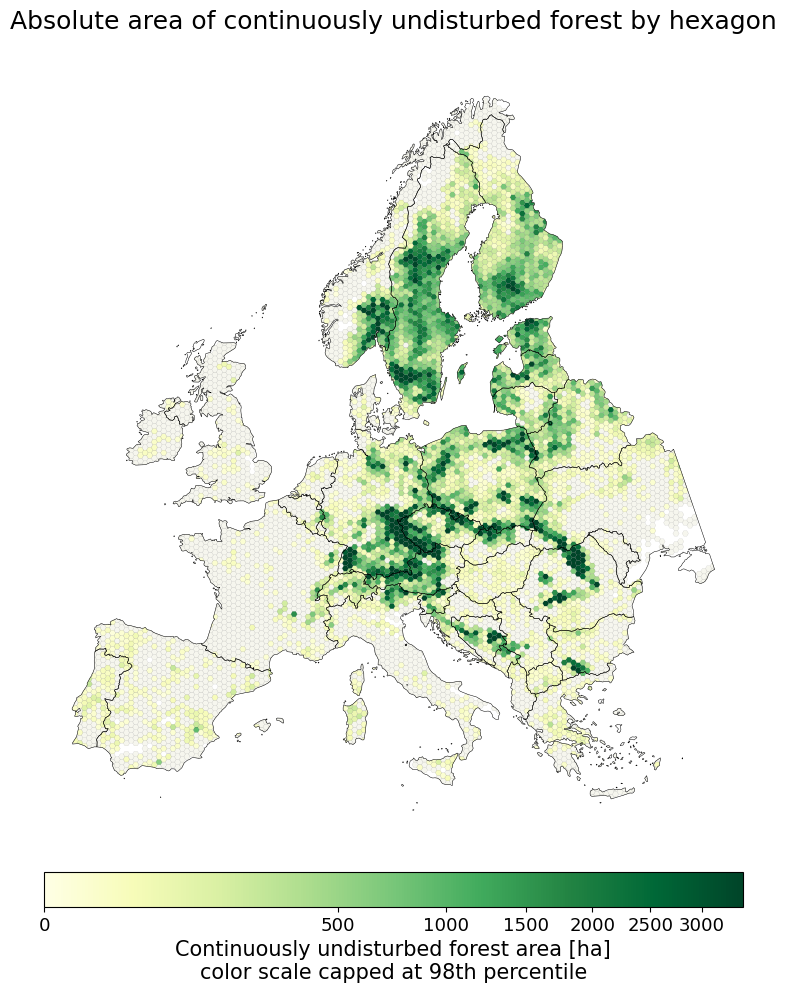

Saved absolute hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.png
Saved absolute hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_absolute_area_by_small_clipped_hexagon_map.svg


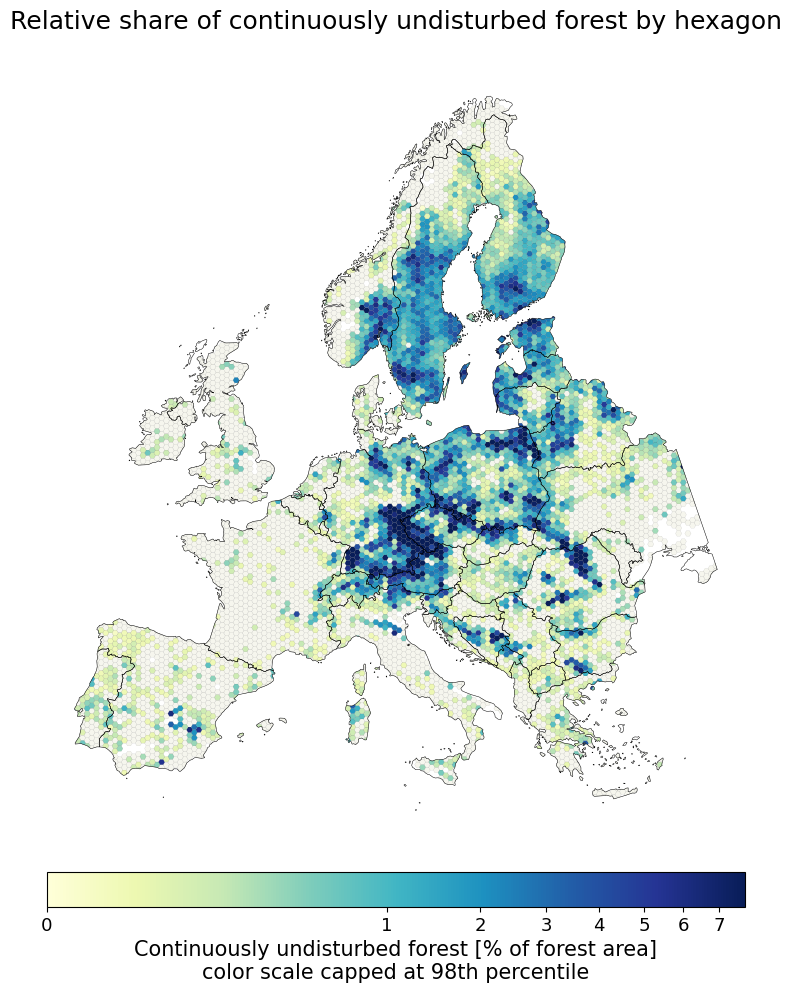

Saved relative hex map PNG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.png
Saved relative hex map SVG: /mnt/eo/EO4Backcasting/figures/old_growth_relative_share_by_small_clipped_hexagon_map.svg


In [13]:
# ------------------------------------------------------------
# Plot: absolute and relative hexagon maps
# ------------------------------------------------------------
abs_vmin = 0
abs_vmax = np.nanpercentile(hexes_plot["oldgrowth_area_ha"], 98)
abs_norm = mpl.colors.PowerNorm(gamma=0.45, vmin=abs_vmin, vmax=abs_vmax)
abs_cmap = plt.get_cmap("YlGn")

rel_vmin = 0
rel_vmax = np.nanpercentile(hexes_plot["oldgrowth_share_percent"], 98)
rel_norm = mpl.colors.PowerNorm(gamma=0.35, vmin=rel_vmin, vmax=rel_vmax)
rel_cmap = plt.get_cmap("YlGnBu")

hexes_plot = hexes_plot.copy()
hexes_plot["oldgrowth_area_ha_plot"] = hexes_plot["oldgrowth_area_ha"].clip(upper=abs_vmax)
hexes_plot["oldgrowth_share_percent_plot"] = hexes_plot["oldgrowth_share_percent"].clip(upper=rel_vmax)

title_size = 18
legend_label_size = 15
legend_tick_size = 13

# Absolute area
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_abs = hexes_plot[(hexes_plot["oldgrowth_area_ha"].isna()) | (hexes_plot["oldgrowth_area_ha"] <= 0)].copy()
hexes_pos_abs = hexes_plot[(hexes_plot["oldgrowth_area_ha"].notna()) & (hexes_plot["oldgrowth_area_ha"] > 0)].copy()

if len(hexes_zero_abs) > 0:
    hexes_zero_abs.plot(color="#f6f6ee", linewidth=0.05, edgecolor="0.3", ax=ax, zorder=1)

hexes_pos_abs.plot(
    column="oldgrowth_area_ha_plot",
    cmap=abs_cmap,
    norm=abs_norm,
    linewidth=0.05,
    edgecolor="0.1",
    ax=ax,
    zorder=2,
)

countries_eur.boundary.plot(ax=ax, color="black", linewidth=0.35, zorder=3)

sm_abs = mpl.cm.ScalarMappable(cmap=abs_cmap, norm=abs_norm)
sm_abs.set_array([])
cbar = fig.colorbar(sm_abs, ax=ax, orientation="horizontal", shrink=0.72, fraction=0.045, pad=0.03)
cbar.set_label(f"{forest_label_cap} area [ha]\ncolor scale capped at 98th percentile", fontsize=legend_label_size)
cbar.ax.tick_params(labelsize=legend_tick_size)

ax.set_title(f"Absolute area of {forest_label} by hexagon", fontsize=title_size, pad=12)
ax.set_axis_off()
plt.tight_layout()

out_png_abs = out_dir / "old_growth_absolute_area_by_small_clipped_hexagon_map.png"
out_svg_abs = out_dir / "old_growth_absolute_area_by_small_clipped_hexagon_map.svg"
fig.savefig(out_png_abs, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_abs, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved absolute hex map PNG:", out_png_abs)
print("Saved absolute hex map SVG:", out_svg_abs)

# Relative share
fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_rel = hexes_plot[(hexes_plot["oldgrowth_share_percent"].isna()) | (hexes_plot["oldgrowth_share_percent"] <= 0)].copy()
hexes_pos_rel = hexes_plot[(hexes_plot["oldgrowth_share_percent"].notna()) & (hexes_plot["oldgrowth_share_percent"] > 0)].copy()

if len(hexes_zero_rel) > 0:
    hexes_zero_rel.plot(color="#f6f6ee", linewidth=0.05, edgecolor="0.3", ax=ax, zorder=1)

hexes_pos_rel.plot(
    column="oldgrowth_share_percent_plot",
    cmap=rel_cmap,
    norm=rel_norm,
    linewidth=0.05,
    edgecolor="0.1",
    ax=ax,
    zorder=2,
)

countries_eur.boundary.plot(ax=ax, color="black", linewidth=0.35, zorder=3)

sm_rel = mpl.cm.ScalarMappable(cmap=rel_cmap, norm=rel_norm)
sm_rel.set_array([])
cbar = fig.colorbar(sm_rel, ax=ax, orientation="horizontal", shrink=0.72, fraction=0.045, pad=0.03)
cbar.set_label(f"{forest_label_cap} [% of forest area]\ncolor scale capped at 98th percentile", fontsize=legend_label_size)
cbar.ax.tick_params(labelsize=legend_tick_size)

ax.set_title(f"Relative share of {forest_label} by hexagon", fontsize=title_size, pad=12)
ax.set_axis_off()
plt.tight_layout()

out_png_rel = out_dir / "old_growth_relative_share_by_small_clipped_hexagon_map.png"
out_svg_rel = out_dir / "old_growth_relative_share_by_small_clipped_hexagon_map.svg"
fig.savefig(out_png_rel, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_rel, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved relative hex map PNG:", out_png_rel)
print("Saved relative hex map SVG:", out_svg_rel)


## 5. Country pie map and simple genus summary

These plots reuse the cached country-by-genus table, so no raster counting is repeated.

Countries in data but without map pie: []


/tmp/ipykernel_675684/693037921.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


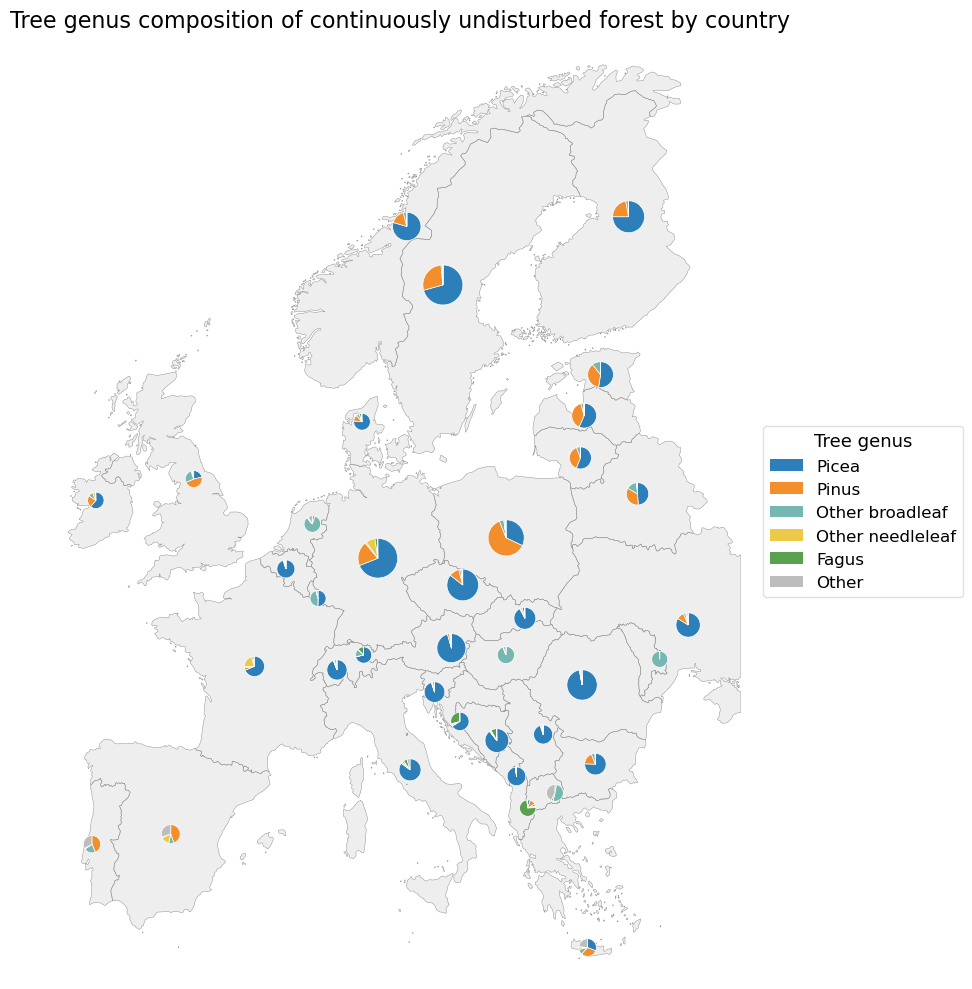

Saved PNG: /mnt/eo/EO4Backcasting/figures/old_growth_country_pie_map_fixed_allcountries.png
Saved SVG: /mnt/eo/EO4Backcasting/figures/old_growth_country_pie_map_fixed_allcountries.svg


In [14]:
# ------------------------------------------------------------
# Plot: country pie map of genus composition
# ------------------------------------------------------------
top_n_genera = 5
min_size = 0.2
max_size = 0.5

# Prepare data
plot_gc = df_gc.copy()
plot_gc["country"] = plot_gc["country"].astype(str).str.strip()
plot_gc["genus"] = plot_gc["genus"].astype(str).str.strip()
plot_gc = plot_gc[plot_gc["genus"] != "No trees"].copy()
if exclude_russia:
    plot_gc = plot_gc[plot_gc["country"] != "Russian Federation"].copy()

top_genera = (
    plot_gc.groupby("genus")["area_ha"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n_genera)
    .index
    .tolist()
)
plot_gc["genus_plot"] = np.where(plot_gc["genus"].isin(top_genera), plot_gc["genus"], "Other")

df_country_genus = plot_gc.groupby(["country", "genus_plot"], as_index=False)["area_ha"].sum()
df_country_total = (
    df_country_genus.groupby("country", as_index=False)["area_ha"]
    .sum()
    .rename(columns={"area_ha": "total_oldgrowth_ha"})
)

pie_table = df_country_genus.pivot(index="country", columns="genus_plot", values="area_ha").fillna(0)
genus_order = [g for g in top_genera if g in pie_table.columns]
if "Other" in pie_table.columns:
    genus_order = genus_order + ["Other"]
pie_table = pie_table[genus_order]

# Prepare map
countries_map = load_europe_countries(target_crs=None, clip_mainland=True).to_crs(4326)
countries_map = countries_map.merge(df_country_total, on="country", how="left")
countries_with_data = countries_map[countries_map["total_oldgrowth_ha"].notna()].copy()
if len(countries_with_data) == 0:
    raise ValueError("No countries with matched data found.")

points = countries_with_data.representative_point()
countries_with_data["x"] = points.x
countries_with_data["y"] = points.y

vals_sqrt = np.sqrt(countries_with_data["total_oldgrowth_ha"].values.astype(float))
vmin, vmax = vals_sqrt.min(), vals_sqrt.max()
if vmax == vmin:
    countries_with_data["pie_size"] = (min_size + max_size) / 2
else:
    countries_with_data["pie_size"] = min_size + ((vals_sqrt - vmin) / (vmax - vmin)) * (max_size - min_size)

# Manual offsets for crowded regions
offsets = {
    "Belgium": (-0.6, 0.15), "Netherlands": (0.6, 0.4), "Luxembourg": (0.35, -0.35),
    "Switzerland": (-0.7, -0.25), "Austria": (0.7, -0.25), "Czechia": (0.7, 0.2),
    "Slovakia": (0.8, 0.0), "Slovenia": (-0.3, -0.5), "Croatia": (0.7, -0.3),
    "Bosnia and Herzegovina": (0.55, -0.2), "Serbia": (0.6, -0.1), "Montenegro": (0.55, -0.45),
    "Kosovo": (0.55, -0.2), "Albania": (0.6, -0.2), "North Macedonia": (0.7, -0.05),
    "Moldova": (0.7, 0.0), "Portugal": (-0.5, -0.1), "Ireland": (-0.4, 0.0), "Denmark": (0.2, 0.4),
}
for country, (dx, dy) in offsets.items():
    idx = countries_with_data["country"] == country
    countries_with_data.loc[idx, "x"] += dx
    countries_with_data.loc[idx, "y"] += dy

missing_pies = sorted(set(df_country_total["country"]) - set(countries_with_data["country"]))
print("Countries in data but without map pie:", missing_pies)

fig, ax = plt.subplots(figsize=(14, 10))
countries_map.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.5, zorder=1)
countries_map.boundary.plot(ax=ax, color="0.55", linewidth=0.35, zorder=2)

for _, row in countries_with_data.iterrows():
    country = row["country"]
    if country not in pie_table.index:
        continue

    values = pie_table.loc[country, genus_order].values.astype(float)
    if values.sum() <= 0:
        continue

    size = row["pie_size"]
    axins = inset_axes(
        ax,
        width=size,
        height=size,
        loc="center",
        bbox_to_anchor=(row["x"], row["y"]),
        bbox_transform=ax.transData,
        borderpad=0,
    )
    axins.pie(
        values,
        colors=[genus_colors.get(g, "#cccccc") for g in genus_order],
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 0.5, "edgecolor": "white"},
    )
    axins.set_aspect("equal")
    axins.set_axis_off()

handles = [Patch(facecolor=genus_colors.get(g, "#cccccc"), edgecolor="none", label=g) for g in genus_order]
ax.legend(handles=handles, title="Tree genus", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, facecolor="white", edgecolor="0.85", fontsize=12, title_fontsize=13)

ax.set_xlim(-11, 35)
ax.set_ylim(34, 72)
ax.set_axis_off()
ax.set_title(f"Tree genus composition of {forest_label} by country", fontsize=16, pad=12)
plt.tight_layout()

out_png = out_dir / "old_growth_country_pie_map_fixed_allcountries.png"
out_svg = out_dir / "old_growth_country_pie_map_fixed_allcountries.svg"
fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)


## 6. Probability distributions by genus

The aligned genus raster and the probability-by-genus sample are loaded if available. Reprojection and sampling are only performed if the cached products are missing.

In [15]:
# ------------------------------------------------------------
# Load or create probability-by-genus sample
# ------------------------------------------------------------
def sample_probability_by_genus(prob_fp, genus_fp, sample_fraction=0.01, max_samples_per_block=3000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []

    with rasterio.open(prob_fp) as prob_src, rasterio.open(genus_fp) as genus_src:
        same_grid = (
            prob_src.crs == genus_src.crs and
            prob_src.shape == genus_src.shape and
            prob_src.transform == genus_src.transform
        )
        if not same_grid:
            raise ValueError("Probability and genus raster are not on the same grid.")

        prob_nodata = prob_src.nodata
        genus_nodata = genus_src.nodata
        total_blocks = sum(1 for _ in prob_src.block_windows(1))
        sample_counter = 0

        for i, (_, window) in enumerate(prob_src.block_windows(1), start=1):
            prob = prob_src.read(1, window=window)
            genus = genus_src.read(1, window=window)

            valid = np.isfinite(prob) & np.isfinite(genus)
            if prob_nodata is not None:
                valid &= prob != prob_nodata
            if genus_nodata is not None:
                valid &= genus != genus_nodata

            valid &= (prob >= 0) & (prob <= 1)
            valid &= genus >= 0

            idx = np.flatnonzero(valid)
            if len(idx) == 0:
                continue

            n_sample = min(int(len(idx) * sample_fraction), max_samples_per_block)
            if n_sample <= 0:
                continue

            chosen = rng.choice(idx, size=n_sample, replace=False)
            samples.append(pd.DataFrame({
                "probability": prob.ravel()[chosen].astype("float32"),
                "genus_code": genus.ravel()[chosen].astype("int32"),
            }))
            sample_counter += n_sample

            if i % 500 == 0:
                print(f"Processed {i:,}/{total_blocks:,} blocks; samples: {sample_counter:,}")

    if not samples:
        raise ValueError("No valid samples found. Check nodata values, raster overlap, and genus codes.")

    return pd.concat(samples, ignore_index=True)

aligned_genus = ensure_aligned_genus()

if prob_genus_sample_csv.exists() and not FORCE_RECOMPUTE:
    df_prob_genus = pd.read_csv(prob_genus_sample_csv)
    print(f"Loaded cached probability-by-genus sample: {prob_genus_sample_csv}")
else:
    df_prob_genus = sample_probability_by_genus(
        prob_fp=prob_fp,
        genus_fp=aligned_genus,
        sample_fraction=0.01,
        max_samples_per_block=3000,
        seed=42,
    )
    df_prob_genus.to_csv(prob_genus_sample_csv, index=False)
    print(f"Written: {prob_genus_sample_csv}")

df_prob_genus = add_genus_names(df_prob_genus)
df_prob_genus = df_prob_genus[df_prob_genus["genus"] != "No trees"].copy()

print(df_prob_genus.shape)
display(df_prob_genus.head())


Using existing aligned genus raster: /mnt/eo/EO4Backcasting/_data_aligned/genus_map_europe_aligned_to_probability_30m.tif
Processed 12,500/277,876 blocks; samples: 131
Processed 42,500/277,876 blocks; samples: 805,742
Processed 43,000/277,876 blocks; samples: 830,475
Processed 43,500/277,876 blocks; samples: 856,155
Processed 44,000/277,876 blocks; samples: 883,849
Processed 44,500/277,876 blocks; samples: 911,624
Processed 45,000/277,876 blocks; samples: 939,854
Processed 45,500/277,876 blocks; samples: 967,802
Processed 46,000/277,876 blocks; samples: 994,085
Processed 46,500/277,876 blocks; samples: 1,020,436
Processed 47,000/277,876 blocks; samples: 1,047,556
Processed 73,000/277,876 blocks; samples: 2,642,807
Processed 73,500/277,876 blocks; samples: 2,675,174
Processed 74,000/277,876 blocks; samples: 2,707,321
Processed 74,500/277,876 blocks; samples: 2,738,648
Processed 75,000/277,876 blocks; samples: 2,768,215
Processed 75,500/277,876 blocks; samples: 2,799,918
Processed 76,000

,probability,genus_code,genus
22,0.472010,6,Other broadleaf
24,0.556381,6,Other broadleaf
26,0.490858,6,Other broadleaf
27,0.355281,2,Pinus
28,0.531198,6,Other broadleaf


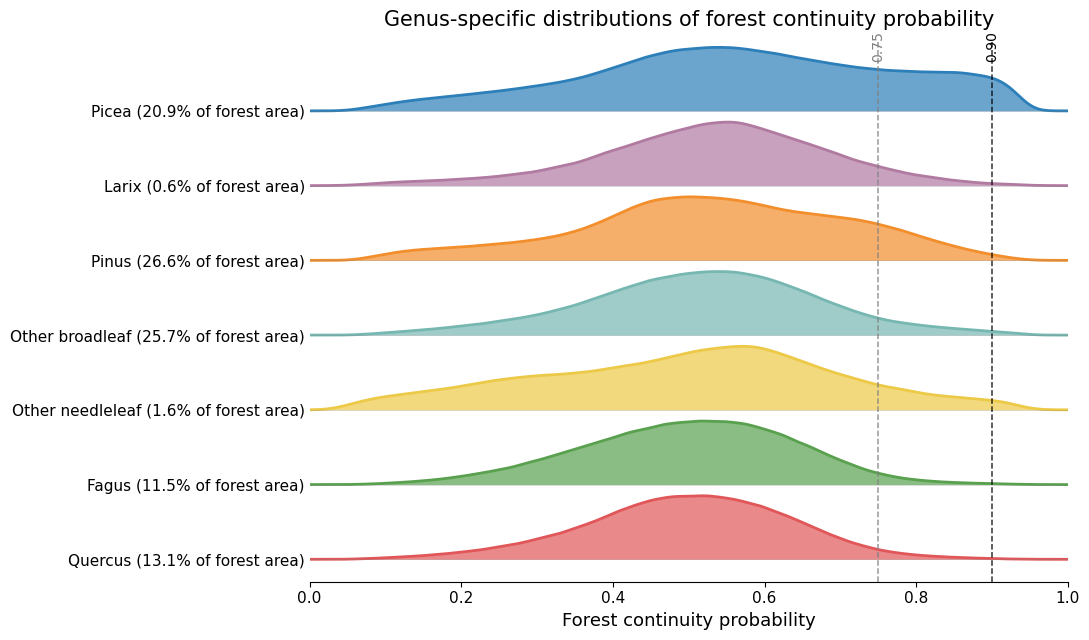

Saved: /mnt/eo/EO4Backcasting/_figures/genus_probability/ridge_probability_by_genus_named_area_share.png


In [21]:
# ------------------------------------------------------------
# Ridge plot: density curves of continuity probability by genus
# with relative forest area share per genus
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ------------------------------------------------------------
# Input / output
# ------------------------------------------------------------

df_plot = df_prob_genus.copy()

prob_genus_fig_dir = Path("/mnt/eo/EO4Backcasting/_figures/genus_probability")
prob_genus_fig_dir.mkdir(parents=True, exist_ok=True)

out_fp = prob_genus_fig_dir / "ridge_probability_by_genus_named_area_share.png"

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

min_n = 50
x_grid = np.linspace(0, 1, 500)
ridge_height = 0.85

# ------------------------------------------------------------
# Clean data
# ------------------------------------------------------------

df_plot = df_plot[
    df_plot["probability"].notna() &
    df_plot["genus"].notna()
].copy()

df_plot = df_plot[
    (df_plot["probability"] >= 0) &
    (df_plot["probability"] <= 1)
].copy()

# Optional: remove non-forest class if present
df_plot = df_plot[df_plot["genus"] != "No trees"].copy()

# ------------------------------------------------------------
# Relative forest area share per genus
# ------------------------------------------------------------
# This assumes that each row represents the same area, e.g. one pixel
# or an equal-area sample point.

genus_area_share = (
    df_plot["genus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .to_dict()
)

# ------------------------------------------------------------
# Order genera by median continuity probability
# ------------------------------------------------------------

order = (
    df_plot.groupby("genus")["probability"]
    .median()
    .sort_values(ascending=True)   # low probability at bottom, high probability at top
    .index
    .tolist()
)

# Remove groups with too few observations
valid_genera = (
    df_plot.groupby("genus")
    .size()
    .loc[lambda x: x >= min_n]
    .index
)

order = [g for g in order if g in valid_genera]
df_plot = df_plot[df_plot["genus"].isin(order)].copy()

# ------------------------------------------------------------
# Compute KDE curves
# ------------------------------------------------------------

ridge_data = []

for i, genus in enumerate(order):
    vals = df_plot.loc[df_plot["genus"] == genus, "probability"].dropna().values

    if len(vals) < min_n:
        continue

    kde = gaussian_kde(vals, bw_method="scott")
    y = kde(x_grid)

    # Normalize each density curve to make ridge heights comparable
    y = y / y.max()

    ridge_data.append({
        "genus": genus,
        "x": x_grid,
        "y": y,
        "offset": i
    })

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6.5))

for item in ridge_data:
    genus = item["genus"]
    x = item["x"]
    y = item["y"] * ridge_height
    offset = item["offset"]

    color = genus_colors.get(genus, "lightgrey")

    ax.fill_between(
        x,
        offset,
        offset + y,
        color=color,
        alpha=0.70,
        linewidth=0
    )

    ax.plot(
        x,
        offset + y,
        color=color,
        linewidth=2.0
    )

    ax.hlines(
        offset,
        xmin=0,
        xmax=1,
        color="grey",
        linewidth=0.5,
        alpha=0.35
    )

# ------------------------------------------------------------
# Probability thresholds
# ------------------------------------------------------------

ax.axvline(0.75, linestyle="--", linewidth=1.1, color="grey", alpha=0.8)
ax.axvline(0.90, linestyle="--", linewidth=1.1, color="black", alpha=0.8)

ax.text(
    0.75,
    len(order) - 0.35,
    "0.75",
    ha="center",
    va="bottom",
    fontsize=10,
    color="grey",
    rotation=90
)

ax.text(
    0.90,
    len(order) - 0.35,
    "0.90",
    ha="center",
    va="bottom",
    fontsize=10,
    color="black",
    rotation=90
)

# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

yticklabels = [
    f"{g} ({genus_area_share.get(g, np.nan):.1f}% of forest area)"
    for g in order
]

ax.set_yticks(range(len(order)))
ax.set_yticklabels(yticklabels)

ax.set_xlim(0, 1)
ax.set_ylim(-0.3, len(order) - 0.05)

ax.set_xlabel("Forest continuity probability", fontsize=13)
ax.set_ylabel("")
ax.set_title(
    "Genus-specific distributions of forest continuity probability",
    fontsize=15,
    pad=10
)

# ------------------------------------------------------------
# Figure note
# ------------------------------------------------------------

ax.text(
    0.0,
    -0.85,
    "",
    ha="left",
    va="top",
    fontsize=10.5,
    color="dimgray",
    transform=ax.transData
)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()

# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------

fig.savefig(out_fp, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_fp)

In [22]:
# ------------------------------------------------------------
# Summary table: probability by genus
# ------------------------------------------------------------
summary = (
    df_prob_genus
    .groupby("genus")
    .agg(
        n=("probability", "size"),
        mean_prob=("probability", "mean"),
        median_prob=("probability", "median"),
        q10=("probability", lambda x: x.quantile(0.10)),
        q90=("probability", lambda x: x.quantile(0.90)),
        share_gt_075=("probability", lambda x: (x > 0.75).mean()),
        share_gt_090=("probability", lambda x: (x > 0.90).mean()),
        share_gt_095=("probability", lambda x: (x > 0.95).mean()),
    )
    .reset_index()
    .sort_values("median_prob", ascending=False)
)

summary_fp = cache_dir / "probability_by_genus_summary.csv"
summary.to_csv(summary_fp, index=False)
print("Written:", summary_fp)
display(summary)


Written: /mnt/eo/EO4Backcasting/_analysis_cache/probability_by_genus_summary.csv


,genus,n,mean_prob,median_prob,q10,q90,share_gt_075,share_gt_090,share_gt_095
4,Picea,2982350,0.567747,0.567307,0.296500,0.841476,0.211140,0.033797,0.000917
1,Larix,89693,0.529781,0.537014,0.337439,0.713930,0.062156,0.002955,0.000167
5,Pinus,3791692,0.532519,0.535014,0.294764,0.761402,0.114474,0.005212,0.000191
2,Other broadleaf,3662327,0.517340,0.521705,0.316396,0.708003,0.061753,0.005056,0.000255
3,Other needleleaf,226173,0.494757,0.511033,0.222025,0.740193,0.091452,0.010598,0.000177
0,Fagus,1639232,0.498664,0.504625,0.312626,0.672533,0.027706,0.001129,0.000034
6,Quercus,1873550,0.498473,0.502999,0.320210,0.667075,0.026250,0.000818,0.000029


In [4]:
# ------------------------------------------------------------
# Inspect forest age HDF5/NetCDF file without GDAL
# ------------------------------------------------------------

import h5py
import os

forest_age_nc = "/mnt/eo/EO4Backcasting/_data/forest_age/GAMIv2-1_2010-2020_100m.nc"

print("Exists:", os.path.exists(forest_age_nc))
print("File size [GB]:", os.path.getsize(forest_age_nc) / 1024**3)

def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print("\nDATASET:", name)
        print("  shape:", obj.shape)
        print("  dtype:", obj.dtype)
        for key, value in obj.attrs.items():
            print("  attr:", key, "=", value)
    elif isinstance(obj, h5py.Group):
        print("\nGROUP:", name)

with h5py.File(forest_age_nc, "r") as f:
    f.visititems(print_h5_structure)

Exists: True
File size [GB]: 217.96297363378108

DATASET: crs
  shape: ()
  dtype: int64
  attr: crs_wkt = b'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'
  attr: semi_major_axis = [6378137.]
  attr: semi_minor_axis = [6356752.31424518]
  attr: inverse_flattening = [298.25722356]
  attr: reference_ellipsoid_name = b'WGS 84'
  attr: longitude_of_prime_meridian = [0.]
  attr: prime_meridian_name = b'Greenwich'
  attr: geographic_crs_name = b'WGS 84'
  attr: horizontal_datum_name = b'World Geodetic System 1984'
  attr: grid_mapping_name = b'latitude_longitude'
  attr: spatial_ref = b'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORIT

In [5]:
# ------------------------------------------------------------
# Decode time values
# ------------------------------------------------------------

import h5py
import pandas as pd

forest_age_nc = "/mnt/eo/EO4Backcasting/_data/forest_age/GAMIv2-1_2010-2020_100m.nc"

with h5py.File(forest_age_nc, "r") as f:
    time_values = f["time"][:]
    time_attrs = dict(f["time"].attrs)

print("time values:", time_values)
print("time attrs:", time_attrs)

# According to metadata: units = days since 2010-01-01
dates = pd.to_datetime("2010-01-01") + pd.to_timedelta(time_values, unit="D")

print("decoded dates:")
for i, d in enumerate(dates):
    print(i, d.date())

time values: [   0 3652]
time attrs: {'_Netcdf4Coordinates': array([3], dtype=int32), 'CLASS': b'DIMENSION_SCALE', 'NAME': b'time', '_Netcdf4Dimid': 3, 'units': b'days since 2010-01-01', 'calendar': b'proleptic_gregorian', 'REFERENCE_LIST': array([(<HDF5 object reference>, 3)],
      dtype={'names': ['dataset', 'dimension'], 'formats': ['O', '<u4'], 'offsets': [0, 8], 'itemsize': 16})}
decoded dates:
0 2010-01-01
1 2020-01-01


In [22]:
# ------------------------------------------------------------
# Load country boundaries for plotting
# ------------------------------------------------------------

import geopandas as gpd

countries_eur = gpd.read_file("/mnt/eo/EO4Backcasting/_data/CNTR_RG_20M_2024_3035.gpkg")

if countries_eur.crs != hex_compare.crs:
    countries_eur = countries_eur.to_crs(hex_compare.crs)

print("Countries CRS:", countries_eur.crs)
print("Hex CRS:", hex_compare.crs)

# Optional: keep only countries intersecting the hexagon extent
xmin, ymin, xmax, ymax = hex_compare.total_bounds
bbox = gpd.GeoDataFrame(
    geometry=[box(xmin, ymin, xmax, ymax)],
    crs=hex_compare.crs
)

countries_eur = gpd.clip(countries_eur, bbox)

Countries CRS: EPSG:3035
Hex CRS: EPSG:3035


Forest-age 98th percentile cap: 142.07709787949184


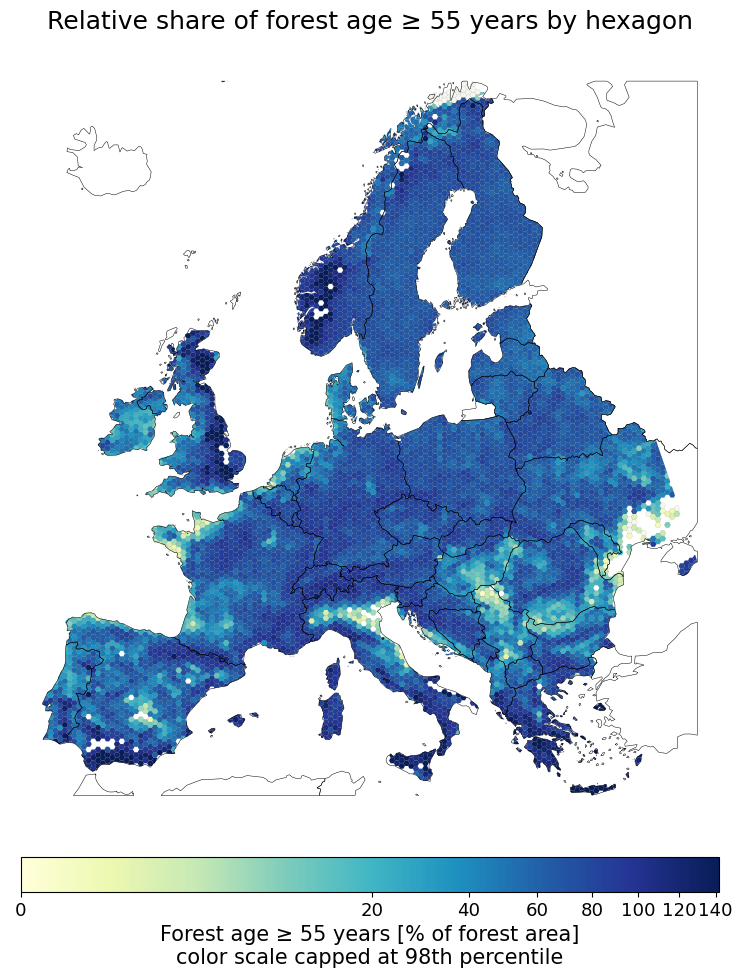

Saved forest-age hex map PNG: /mnt/eo/EO4Backcasting/_analysis/forest_age_comparison/forest_age_ge_55_relative_share_by_small_clipped_hexagon_map.png
Saved forest-age hex map SVG: /mnt/eo/EO4Backcasting/_analysis/forest_age_comparison/forest_age_ge_55_relative_share_by_small_clipped_hexagon_map.svg


In [23]:
# ------------------------------------------------------------
# Plot forest-age map in the same style as prediction hex map
# Apples-to-apples metric:
# forest_age_ge_55_share_percent = age>=55 area / forest_area_ha * 100
# ------------------------------------------------------------

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

age_threshold = 55

prediction_col = "oldgrowth_share_percent"
age_share_col = f"forest_age_ge_{age_threshold}_share_percent"
coverage_col = "forest_age_coverage_percent_of_forest"

forest_age_label = f"forest age ≥ {age_threshold} years"
forest_age_label_cap = f"Forest age ≥ {age_threshold} years"

title_size = 18
legend_label_size = 15
legend_tick_size = 13

rel_cmap = plt.get_cmap("YlGnBu")
zero_color = "#f6f6ee"

out_dir = Path("/mnt/eo/EO4Backcasting/_analysis/forest_age_comparison")
out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Cap at 98th percentile, like your prediction map
# Option A: individual cap for forest-age map
# ------------------------------------------------------------

age_rel_vmin = 0
age_rel_vmax = np.nanpercentile(hex_compare[age_share_col], 98)

age_rel_norm = mpl.colors.PowerNorm(
    gamma=0.35,
    vmin=age_rel_vmin,
    vmax=age_rel_vmax
)

hex_compare = hex_compare.copy()

hex_compare[f"{age_share_col}_plot"] = (
    hex_compare[age_share_col]
    .clip(upper=age_rel_vmax)
)

print("Forest-age 98th percentile cap:", age_rel_vmax)

# ------------------------------------------------------------
# Plot forest-age relative share map
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

hexes_zero_age = hex_compare[
    (hex_compare[age_share_col].isna()) |
    (hex_compare[age_share_col] <= 0)
].copy()

hexes_pos_age = hex_compare[
    (hex_compare[age_share_col].notna()) &
    (hex_compare[age_share_col] > 0)
].copy()

if len(hexes_zero_age) > 0:
    hexes_zero_age.plot(
        color=zero_color,
        linewidth=0.05,
        edgecolor="0.3",
        ax=ax,
        zorder=1
    )

hexes_pos_age.plot(
    column=f"{age_share_col}_plot",
    cmap=rel_cmap,
    norm=age_rel_norm,
    linewidth=0.05,
    edgecolor="0.1",
    ax=ax,
    zorder=2
)

countries_eur.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.35,
    zorder=3
)

sm_age = mpl.cm.ScalarMappable(
    cmap=rel_cmap,
    norm=age_rel_norm
)
sm_age.set_array([])

cbar = fig.colorbar(
    sm_age,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    fraction=0.045,
    pad=0.03
)

cbar.set_label(
    f"{forest_age_label_cap} [% of forest area]\n"
    "color scale capped at 98th percentile",
    fontsize=legend_label_size
)

cbar.ax.tick_params(labelsize=legend_tick_size)

ax.set_title(
    f"Relative share of {forest_age_label} by hexagon",
    fontsize=title_size,
    pad=12
)

ax.set_axis_off()
plt.tight_layout()

out_png_age = out_dir / f"forest_age_ge_{age_threshold}_relative_share_by_small_clipped_hexagon_map.png"
out_svg_age = out_dir / f"forest_age_ge_{age_threshold}_relative_share_by_small_clipped_hexagon_map.svg"

fig.savefig(out_png_age, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(out_svg_age, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved forest-age hex map PNG:", out_png_age)
print("Saved forest-age hex map SVG:", out_svg_age)

In [32]:
# ------------------------------------------------------------
# Save current analysis objects before kernel restart
# ------------------------------------------------------------

import os
import pickle

backup_dir = "/mnt/eo/EO4Backcasting/_analysis/session_backups"
os.makedirs(backup_dir, exist_ok=True)

objects_to_save = {}

for obj_name in [
    "df_total",
    "df_genus",
    "df_ecoregion",
    "df_ecoregion_genus",
    "df_class_check",
    "thresholds",
    "prob_fp",
    "genus_fp",
    "ecoregion_fp",
    "out_dir",
    "px_area_ha",
    "counts_by_genus",
    "counts_by_ecoregion",
    "counts_by_ecoregion_genus",
    "total_by_genus",
    "total_by_ecoregion",
    "total_by_ecoregion_genus",
]:
    if obj_name in globals():
        objects_to_save[obj_name] = globals()[obj_name]

backup_fp = os.path.join(backup_dir, "backcasting_threshold_session_backup.pkl")

with open(backup_fp, "wb") as f:
    pickle.dump(objects_to_save, f)

print("Saved backup:", backup_fp)
print("Saved objects:", list(objects_to_save.keys()))

Saved backup: /mnt/eo/EO4Backcasting/_analysis/session_backups/backcasting_threshold_session_backup.pkl
Saved objects: ['prob_fp', 'genus_fp', 'out_dir']


In [ ]:
# ------------------------------------------------------------
# Load cached hexagon GPKG and plot relative old-growth share
# Values < 0.5% in very light grey
# Linear color scale fixed to 0–10%
# Light grey polygon borders
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

hex_gpkg = Path(
    "/mnt/eo/EO4Backcasting/_analysis_cache/"
    "continuously_undisturbed_by_small_clipped_hexagon.gpkg"
)

out_dir = Path("/mnt/eo/EO4Backcasting/_figs")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / "oldgrowth_share_hexagons_linear_0_10_lowvals_lt_0_5_grey.png"


# ------------------------------------------------------------
# Load hexagons
# ------------------------------------------------------------

hexes_plot = gpd.read_file(hex_gpkg, layer="hexes")

print("Loaded:", hex_gpkg)
print("CRS:", hexes_plot.crs)
print("Number of hexagons:", len(hexes_plot))
print("Columns:", list(hexes_plot.columns))


# ------------------------------------------------------------
# Select relative variable
# ------------------------------------------------------------

rel_col = "oldgrowth_share_percent"

hexes_plot = hexes_plot[
    hexes_plot[rel_col].notna()
].copy()

print(hexes_plot[rel_col].describe())


# ------------------------------------------------------------
# Threshold and split
# ------------------------------------------------------------

low_threshold = 0.1

hexes_low = hexes_plot[hexes_plot[rel_col] < low_threshold].copy()
hexes_high = hexes_plot[hexes_plot[rel_col] >= low_threshold].copy()

print(f"Hexagons with {rel_col} < {low_threshold}: {len(hexes_low)}")
print(f"Hexagons with {rel_col} >= {low_threshold}: {len(hexes_high)}")


# ------------------------------------------------------------
# Linear color scaling: fixed 0–10%
# ------------------------------------------------------------

vmin = 0
vmax = 7

norm = Normalize(vmin=vmin, vmax=vmax)

cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_bad(alpha=0)


# ------------------------------------------------------------
# Optional: load country boundaries if function exists
# ------------------------------------------------------------

try:
    countries_eur = load_europe_countries(
        target_crs=hexes_plot.crs,
        clip_mainland=True
    )
    plot_countries = True
except NameError:
    countries_eur = None
    plot_countries = False
    print("load_europe_countries() not defined; plotting without country boundaries.")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# Values below threshold: very light grey
if len(hexes_low) > 0:
    hexes_low.plot(
        ax=ax,
        color="0.94",
        linewidth=0.18,
        edgecolor="0.82",
        alpha=1.0,
        zorder=1
    )

# Values >= threshold: linear 0–10% color scale
if len(hexes_high) > 0:
    hexes_high.plot(
        column=rel_col,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0.18,
        edgecolor="0.82",
        alpha=1.0,
        zorder=2
    )

# Country boundaries
if plot_countries:
    countries_eur.boundary.plot(
        ax=ax,
        linewidth=0.35,
        edgecolor="0.35",
        alpha=0.75,
        zorder=10
    )

# Continuous colorbar, linear 0–10%
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.72,
    pad=0.02,
    ticks=np.arange(0, 11, 2),
    extend="max"
)

cbar.set_label("Continuously undisturbed forest area (%)")
cbar.outline.set_linewidth(0.6)

# Legend entry for grey threshold class
legend_handles = [
    Patch(
        facecolor="0.94",
        edgecolor="0.82",
        label=f"< {low_threshold}%"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.9,
    fontsize=9
)

ax.set_axis_off()

fig.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Written:", out_png)

Loaded: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_by_small_clipped_hexagon.gpkg
CRS: EPSG:3035
Number of hexagons: 7553
Columns: ['hex_id', 'forest_pixels', 'oldgrowth_pixels', 'forest_area_ha', 'oldgrowth_area_ha', 'oldgrowth_share_percent', 'geometry']
count    7553.000000
mean        0.858823
std         2.357489
min         0.000000
25%         0.000000
50%         0.027019
75%         0.588980
max        42.330139
Name: oldgrowth_share_percent, dtype: float64
Hexagons with oldgrowth_share_percent < 0.1: 4472
Hexagons with oldgrowth_share_percent >= 0.1: 3081
load_europe_countries() not defined; plotting without country boundaries.
